In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_friedman1
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import pandas as pd
import time

import sys

sys.path.append("../..")

In [2]:
from src.models.kernel_regression import KernelRegression
from src.conformal_prediction.oracle_cp import OracleConformalPredictor
from src.conformal_prediction.split_cp import SplitConformalPredictor
from src.conformal_prediction.ustable_cp import UStableConformalPredictor
from src.conformal_prediction.stable_cp import StableConformalPredictor
from src.conformal_prediction.influence_func_cp import (
    InfluenceFunctionConformalPredictor,
)
from src.conformal_prediction.utils import interval_length

Utils

In [4]:
def sample_data(sample_size):
    sample_size_p1 = sample_size + 1

    input_points, output_points = make_friedman1(sample_size_p1)
    output_points = output_points.reshape(-1, 1)

    input_points = StandardScaler().fit_transform(input_points)
    output_points = StandardScaler().fit_transform(output_points)

    train_input_points = input_points[:-1, :].reshape(
        sample_size, input_points.shape[1]
    )
    train_output_points = output_points[:-1, :].reshape(
        sample_size, output_points.shape[1]
    )
    test_input_point = input_points[-1, :].reshape(1, -1)
    test_output_point = output_points[-1, :].reshape(1, -1)

    return train_input_points, train_output_points, test_input_point, test_output_point

In [5]:
def make_region_predictor(
    conformal_predictor,
    train_input_points,
    train_output_points,
    test_input_point,
    test_output_point,
):
    if conformal_predictor.name == "oracle_cp":
        region_predictor = conformal_predictor.fit_predict(
            train_input_points, train_output_points, test_input_point, test_output_point
        )
    elif conformal_predictor.name == "scp":
        (
            proper_train_input_points,
            calib_input_points,
            proper_train_output_points,
            calib_output_points,
        ) = train_test_split(train_input_points, train_output_points, train_size=0.5)
        conformal_predictor.predictor.fit(proper_train_input_points, proper_train_output_points)
        conformal_predictor.fit(calib_input_points, calib_output_points)
        region_predictor = conformal_predictor.predict(test_input_point)
    else:
        region_predictor = conformal_predictor.fit_predict(
            train_input_points,
            train_output_points,
            test_input_point,
        )
    return region_predictor

In [6]:
# This I took from Ndiaye's stable conformal
def record(
    conformal_predictor,
    train_input_points,
    train_output_points,
    test_input_point,
    test_output_point,
    confidence_control_level,
):
    tic = time.time()
    region_predictor = make_region_predictor(
        conformal_predictor,
        train_input_points,
        train_output_points,
        test_input_point,
        test_output_point,
    )
    if conformal_predictor.name in ["ustable_cp", "stable_cp", "influence_function_cp"]:
        prediction_region = region_predictor(confidence_control_level)[0]["upper"]
    else:
        prediction_region = region_predictor(confidence_control_level)[0]

    tac = time.time()

    return np.array(
        [
            np.float64(test_output_point[0] in prediction_region),
            interval_length(prediction_region),
            tac - tic,
        ],
        dtype=object,
    )

Parameters

In [7]:
loss_name = "log_cosh"
loss_params = {"alpha": 1.0}

# loss_name = "pseudo_huber"
# loss_params = {"alpha": 1.}

# loss_name = "smoothed_pinball"
# loss_params = {"alpha":1., "tau":0.5}

confidence_control_level = 0.1
n_repet = 100
sample_size = 200

Instantiate conformal predictors

In [8]:
predictor = KernelRegression(
    lam=0.25,
    kernel="laplacian",
    loss_name=loss_name,
    loss_params=loss_params,
)

In [9]:
conformal_predictor_makers = [
    OracleConformalPredictor,
    SplitConformalPredictor,
    UStableConformalPredictor,
    StableConformalPredictor,
    InfluenceFunctionConformalPredictor,
]
conformal_predictors = [
    conformal_predictor_maker(predictor)
    for conformal_predictor_maker in conformal_predictor_makers
]
conformal_predictors_names = [
    conformal_predictor.name for conformal_predictor in conformal_predictors
]

In [11]:
columns = ["coverage", "length", "time"]

results = {}
for key in conformal_predictors_names:
    results[key] = pd.DataFrame(np.zeros((n_repet, len(columns))),
                            columns=columns)

In [12]:
for i_repet in tqdm(range(n_repet)):
    train_input_points, train_output_points, test_input_point, test_output_point = (
        sample_data(sample_size)
    )
    result = {
        conformal_predictor.name: record(
            conformal_predictor,
            train_input_points,
            train_output_points,
            test_input_point,
            test_output_point,
            confidence_control_level,
        )
        for conformal_predictor in conformal_predictors
    }

    for key in results.keys():
        results[key].iloc[i_repet] = result[key]

100%|██████████| 100/100 [01:22<00:00,  1.22it/s]


In [13]:
np.save("friedman1" + ".npy", results)

In [2]:
def set_style():
    plt.rcParams["text.usetex"] = True
    font = {"family": "normal", "weight": "bold", "size": 22}
    plt.rc("font", **font)

In [14]:
def plot(dataset, colors, names):
    def labelize(name, df, norm=1):

        cov = r"$\overline{cov}$ = "
        # mean_cov = str(df["coverage"].mean())
        mean_cov = str(np.round(df["coverage"].mean(), 2))
        Ts = r"$\overline{T}$ = "
        mean_time = str(np.round(df["time"].mean() / norm, 2))

        return name + " \n" + cov + mean_cov + "\n" + Ts + mean_time
        # return name + " \n" + cov + mean_cov

    name = dataset
    res = np.load(name + ".npy", allow_pickle=True).tolist()

    labels = []
    df_length = []
    for key in res.keys():
        # print("\n ", key, "\n", res[key].mean(), "\n")
        labels += [labelize(names[key], res[key], res["oracle_cp"]["time"].mean())]
        df_length += [res[key]["length"]]

    fig, ax = plt.subplots(figsize=(13,5))
    box = ax.boxplot(df_length, patch_artist=True)
    ax.set_ylabel("Length")
    # plt.title(method + " : " + dataset)

    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)

    ax.grid(False)
    ax.set_xticks(np.arange(1, len(labels) + 1), labels)
    fig.tight_layout()
    ax.set_title("Comparison of lengths of prediction regions")
    # name = method + "_" + dataset + ".pdf"

    # if save_figure:
    #     plt.savefig(name, format="pdf")

    # if show_bench:
    #     plt.show()

    return fig

In [4]:
CP_colors = ["#0E0E0E", "#117733", "#882255", "#DDCC77", "#77DDA5"]

In [10]:
names = {
    "oracle_cp":"OracleCP",
    "scp":"SplitCP",
    "ustable_cp":"UStableCP",
    "stable_cp":"LocStableCP",
    "influence_function_cp":"InfluenceFunctionCP"
}

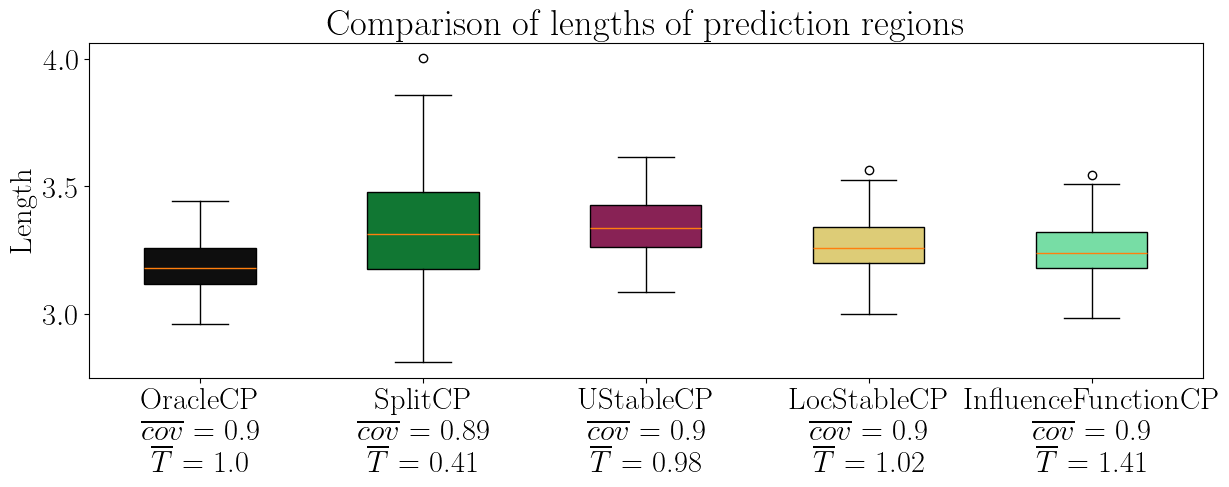

In [15]:
set_style()
fig = plot("friedman1", CP_colors, names)

In [18]:
fig.savefig("friedman1.eps", format="eps", bbox_inches="tight")

Failed to find a Ghostscript installation.  Distillation step skipped.
